### Project Config Steup

In [1]:
# ================================
# Project Configuration
# ================================

from pathlib import Path
import os
import random

import numpy as np
import pandas as pd
import torch

# Hugging Face
from datasets import load_dataset
from huggingface_hub import hf_hub_download

# Visualization
import matplotlib.pyplot as plt

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

# -------------------------------
# Reproducibility
# -------------------------------

SUBSAMPLE_SEED = 42

def set_seed(seed=SUBSAMPLE_SEED):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

# -------------------------------
# Project Paths
# -------------------------------

PROJECT_ROOT = Path("/kaggle/working")

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
REPORT_DIR = PROJECT_ROOT / "reports"

for folder in [RAW_DIR, PROCESSED_DIR, REPORT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project initialized")
print(f"Working Directory : {PROJECT_ROOT}")
print(f"GPU : {torch.cuda.get_device_name(0)}")

Project initialized
Working Directory : /kaggle/working
GPU : Tesla T4


### Getting Data

In [2]:
# ==========================================
# Download IndicXNLI (Hindi & Telugu)
# ==========================================

from huggingface_hub import hf_hub_download

REPO_ID = "Divyanshu/indicxnli"

FILES = [

    # Hindi
    "forward/train/xnli_hi.json",
    "forward/dev/xnli_hi.json",
    "forward/test/xnli_hi.json",

    # Telugu
    "forward/train/xnli_te.json",
    "forward/dev/xnli_te.json",
    "forward/test/xnli_te.json",

]

for file in FILES:

    path = hf_hub_download(
        repo_id=REPO_ID,
        repo_type="dataset",
        filename=file,
        local_dir=RAW_DIR,
        local_dir_use_symlinks=False
    )

    print(path)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


forward/train/xnli_hi.json:   0%|          | 0.00/219M [00:00<?, ?B/s]

/kaggle/working/data/raw/forward/train/xnli_hi.json


forward/dev/xnli_hi.json:   0%|          | 0.00/1.32M [00:00<?, ?B/s]

/kaggle/working/data/raw/forward/dev/xnli_hi.json


...

/kaggle/working/data/raw/forward/train/xnli_te.json


forward/dev/xnli_te.json:   0%|          | 0.00/1.33M [00:00<?, ?B/s]

/kaggle/working/data/raw/forward/dev/xnli_te.json


forward/test/xnli_te.json:   0%|          | 0.00/2.70M [00:00<?, ?B/s]

/kaggle/working/data/raw/forward/test/xnli_te.json


### JSON Loader

In [22]:
# ==========================================
# Generic IndicXNLI Loader (Final)
# ==========================================

import json
import pandas as pd

def load_xnli(language: str, split: str) -> pd.DataFrame:
    """
    Load IndicXNLI dataset.

    Parameters
    ----------
    language : str
        "hi", "te"

    split : str
        "train", "dev", "test"

    Returns
    -------
    DataFrame
    """

    path = RAW_DIR / "forward" / split / f"xnli_{language}.json"

    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    # train -> {'train':[...]}
    # dev   -> {'validation':[...]}
    # test  -> {'test':[...]}
    records = next(iter(data.values()))

    df = pd.DataFrame(records)

    df["language"] = language
    df["split"] = split

    return df

In [23]:
hi_train = load_xnli("hi", "train")
hi_dev   = load_xnli("hi", "dev")
hi_test  = load_xnli("hi", "test")

te_train = load_xnli("te", "train")
te_dev   = load_xnli("te", "dev")
te_test  = load_xnli("te", "test")

In [24]:
for name, df in {
    "HI Train": hi_train,
    "HI Dev": hi_dev,
    "HI Test": hi_test,
    "TE Train": te_train,
    "TE Dev": te_dev,
    "TE Test": te_test,
}.items():

    print(name, df.shape)

HI Train (392702, 5)
HI Dev (2490, 5)
HI Test (5010, 5)
TE Train (392702, 5)
TE Dev (2490, 5)
TE Test (5010, 5)


In [25]:
print(hi_train.columns)

display(hi_train.head())

hi_train.info()

Index(['premise', 'hypothesis', 'label', 'language', 'split'], dtype='object')


,premise,hypothesis,label,language,split
0,अवधारणात्मक रूप से क्रीम स्किमिंग के दो बुनियादी आयाम हैं-उत्पाद और भूगोल।,उत्पाद और भूगोल क्रीम स्किमिंग का काम करते हैं।,1,hi,train
1,आप मौसम के दौरान पता है और मुझे लगता है कि अपने स्तर पर उह आप उन्हें अगले स्तर पर खो देते हैं अगर वे मूल टीम को याद करने का फैसला करने के लिए बहादुर ट्रिपल ए से एक आदमी को याद करने के लिए कॉल करने का फैसला करता है तो एक दोहरा एक आदमी उसे बदलने के लिए ऊपर चला जाता है और एक आदमी उसे बदलने के लिए ऊपर चला जाता है,अगर लोग याद करते हैं तो आप निम्नलिखित स्तर पर चीजें खो देते हैं।,0,hi,train
2,हमारी संख्या में से एक आपके निर्देशों का बारीकी से पालन करेगी।,मेरी टीम का एक सदस्य आपके आदेशों को बहुत सटीकता के साथ निष्पादित करेगा।,0,hi,train
3,तुम्हें कैसे पता? यह सब फिर से उनकी जानकारी है.,यह जानकारी उनके पास है।,0,hi,train
4,हाँ मैं आपको बताती हूँ कि अगर आप उन टेनिस जूतों में से कुछ की कीमत तय करते हैं तो मैं देख सकती हूँ कि क्यों अब आप जानते हैं कि वे सौ डॉलर की रेंज में उठ रहे हैं,टेनिस जूतों की कीमतों की एक श्रृंखला है।,1,hi,train


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392702 entries, 0 to 392701
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   premise     392702 non-null  object
 1   hypothesis  392702 non-null  object
 2   label       392702 non-null  int64 
 3   language    392702 non-null  object
 4   split       392702 non-null  object
dtypes: int64(1), object(4)
memory usage: 15.0+ MB


In [26]:
# ==========================================
# Dataset Profiler
# ==========================================

import pandas as pd

def profile_dataset(df, name):

    print("=" * 80)
    print(name)
    print("=" * 80)

    print(f"Shape             : {df.shape}")
    print(f"Language          : {df['language'].iloc[0]}")
    print(f"Split             : {df['split'].iloc[0]}")

    print("\nMissing Values")
    print(df.isnull().sum())

    print("\nDuplicate Sentence Pairs")
    print(
        df.duplicated(
            subset=["premise", "hypothesis", "label"]
        ).sum()
    )

    print("\nLabel Distribution")
    print(df["label"].value_counts().sort_index())

    # Text Statistics
    stats = pd.DataFrame({
        "Premise Words": df["premise"].str.split().str.len(),
        "Hypothesis Words": df["hypothesis"].str.split().str.len(),
        "Premise Characters": df["premise"].str.len(),
        "Hypothesis Characters": df["hypothesis"].str.len()
    })

    print("\nText Statistics")
    print(stats.describe())

In [27]:
profile_dataset(hi_train, "Hindi Train")

profile_dataset(te_train, "Telugu Train")

Hindi Train
Shape             : (392702, 5)
Language          : hi
Split             : train

Missing Values
premise       0
hypothesis    0
label         0
language      0
split         0
dtype: int64

Duplicate Sentence Pairs
77

Label Distribution
label
0    130899
1    130900
2    130903
Name: count, dtype: int64

Text Statistics
       Premise Words  Hypothesis Words  Premise Characters  \
count  392702.000000     392702.000000       392702.000000   
mean       22.580738         11.458600          110.920721   
std        15.921039          5.177823           76.494775   
min         1.000000          1.000000            3.000000   
25%        11.000000          8.000000           55.000000   
50%        19.000000         11.000000           96.000000   
75%        30.000000         14.000000          149.000000   
max       196.000000        136.000000          843.000000   

       Hypothesis Characters  
count          392702.000000  
mean               56.245530  
std         

In [28]:
LABEL_MAP = {
    0: "Entailment",
    1: "Neutral",
    2: "Contradiction"
}

hi_train["label_name"] = hi_train["label"].map(LABEL_MAP)
te_train["label_name"] = te_train["label"].map(LABEL_MAP)

In [29]:
import matplotlib.pyplot as plt

def plot_label_distribution(df, title):

    counts = (
        df["label_name"]
        .value_counts()
        .reindex(["Entailment", "Neutral", "Contradiction"])
    )

    plt.figure(figsize=(6,4))
    plt.bar(counts.index, counts.values)

    plt.title(title)
    plt.xlabel("Label")
    plt.ylabel("Samples")

    plt.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

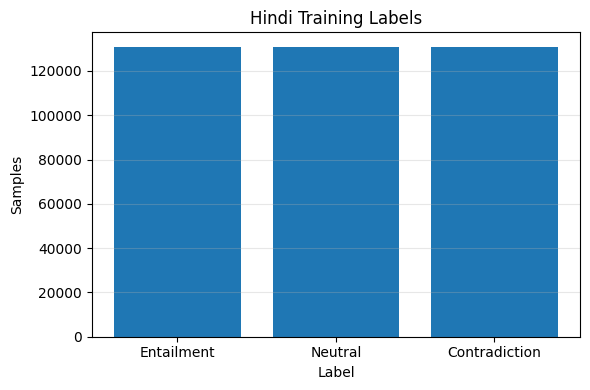

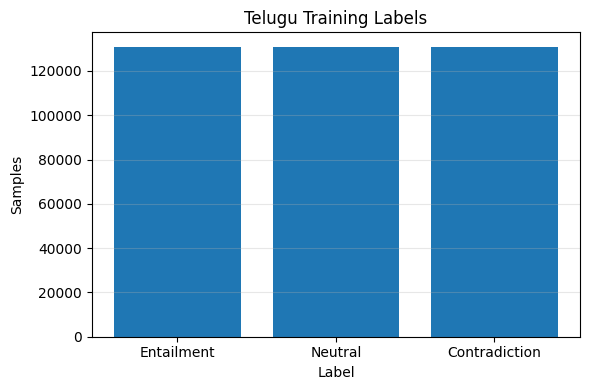

In [30]:
plot_label_distribution(hi_train, "Hindi Training Labels")

plot_label_distribution(te_train, "Telugu Training Labels")

In [31]:
def plot_sentence_lengths(df, column, title):

    lengths = df[column].str.split().str.len()

    plt.figure(figsize=(8,4))

    plt.hist(lengths, bins=50)

    plt.title(title)
    plt.xlabel("Words")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

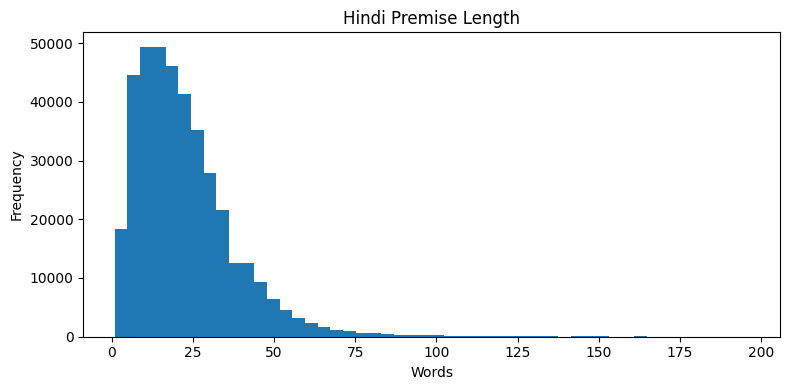

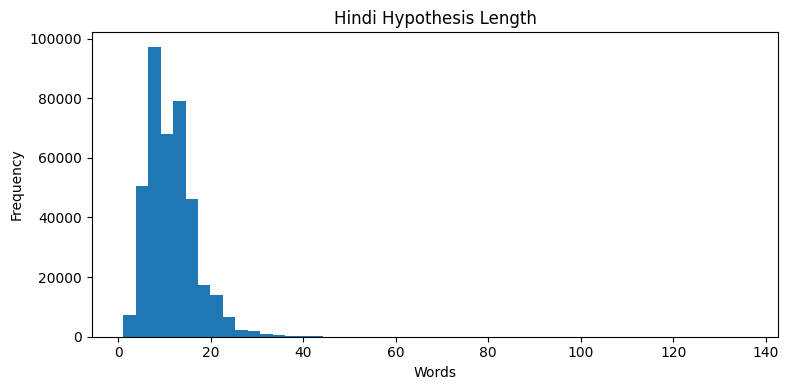

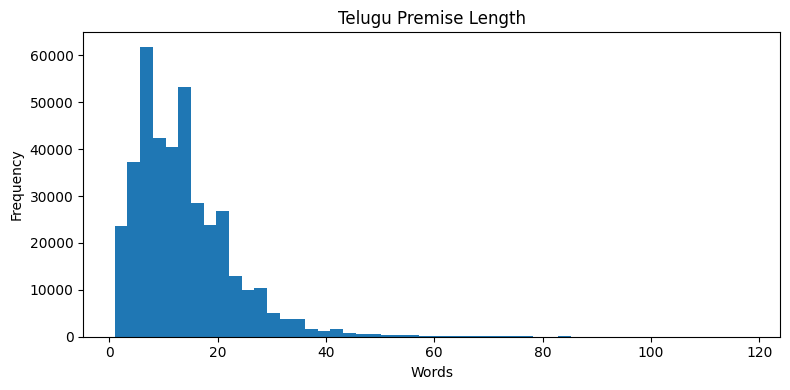

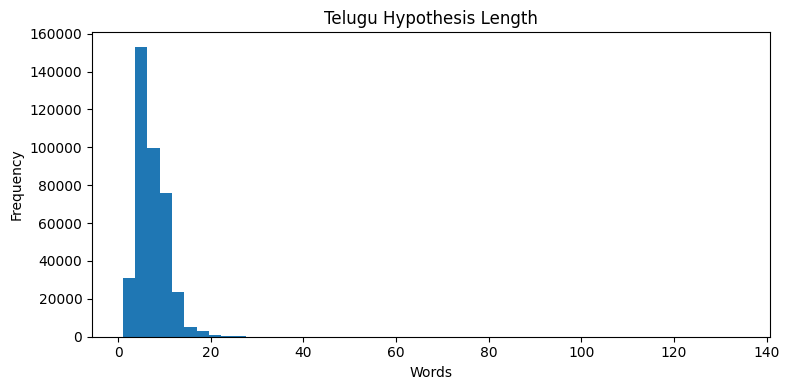

In [32]:
plot_sentence_lengths(
    hi_train,
    "premise",
    "Hindi Premise Length"
)

plot_sentence_lengths(
    hi_train,
    "hypothesis",
    "Hindi Hypothesis Length"
)

plot_sentence_lengths(
    te_train,
    "premise",
    "Telugu Premise Length"
)

plot_sentence_lengths(
    te_train,
    "hypothesis",
    "Telugu Hypothesis Length"
)

In [33]:
def check_split_overlap(df1, df2, name1, name2):
    cols = ["premise", "hypothesis", "label"]

    overlap = (
        pd.merge(
            df1[cols],
            df2[cols],
            on=cols,
            how="inner"
        )
        .drop_duplicates()
    )

    print(f"{name1} ↔ {name2}")
    print(f"Overlap : {len(overlap)}")

In [34]:
check_split_overlap(hi_train, hi_dev, "HI Train", "HI Dev")
check_split_overlap(hi_train, hi_test, "HI Train", "HI Test")
check_split_overlap(hi_dev, hi_test, "HI Dev", "HI Test")

check_split_overlap(te_train, te_dev, "TE Train", "TE Dev")
check_split_overlap(te_train, te_test, "TE Train", "TE Test")
check_split_overlap(te_dev, te_test, "TE Dev", "TE Test")

HI Train ↔ HI Dev
Overlap : 0
HI Train ↔ HI Test
Overlap : 0
HI Dev ↔ HI Test
Overlap : 0
TE Train ↔ TE Dev
Overlap : 0
TE Train ↔ TE Test
Overlap : 0
TE Dev ↔ TE Test
Overlap : 0
